In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In this step, the necessary Python libraries are imported. Pandas is used for data manipulation, NumPy for numerical operations, Matplotlib for visualization, and SciPy for statistical tests. Display settings are adjusted to show all columns and more rows for better inspection.

In [26]:
df = pd.read_csv("world_university_survey_dataset.csv")
df.head()

,student_id,student_name,age,gender,country,university,program_level,field_of_study,year_of_study,tuition_usd,scholarship,online_classes,campus_facilities_rating,teaching_quality_rating,overall_satisfaction
0,1,Dustin Shaw,30,Other,Netherlands,"Herrera, Juarez and Williams University",Bachelor,Data Science,5,47419,Yes,No,1,2,Satisfied
1,2,Richard Hughes,20,Female,UK,Norton LLC University,Master,Computer Science,4,6419,Yes,Yes,3,4,Satisfied
2,3,John Cooper,34,Female,UK,Berg Inc University,PhD,Engineering,3,7126,Yes,No,3,5,Very Dissatisfied
3,4,Travis Thompson,19,Female,Japan,Johnson-Gordon University,Bachelor,Business,2,13564,No,Yes,4,4,Dissatisfied
4,5,Jessica Campbell,34,Female,Japan,Nixon-Dodson University,PhD,Social Sciences,3,2531,Yes,Yes,5,3,Dissatisfied


The dataset is loaded from a CSV file into a DataFrame. The head() function displays the first few rows to verify that the data has been loaded correctly.

In [27]:
print("Satır ve sütun sayısı:", df.shape)
print("\nSütunlar:")
print(df.columns.tolist())

Satır ve sütun sayısı: (1000, 15)

Sütunlar:
['student_id', 'student_name', 'age', 'gender', 'country', 'university', 'program_level', 'field_of_study', 'year_of_study', 'tuition_usd', 'scholarship', 'online_classes', 'campus_facilities_rating', 'teaching_quality_rating', 'overall_satisfaction']


This step provides an overview of the dataset. The shape shows the number of rows and columns, while the list of column names helps to understand the available variables.

In [28]:
print(df.dtypes)

student_id                   int64
student_name                object
age                          int64
gender                      object
country                     object
university                  object
program_level               object
field_of_study              object
year_of_study                int64
tuition_usd                  int64
scholarship                 object
online_classes              object
campus_facilities_rating     int64
teaching_quality_rating      int64
overall_satisfaction        object
dtype: object


This step displays the data types of each column. It helps to distinguish between numerical and categorical variables, which is important for further analysis.

In [29]:
df.isna().sum()

,0
student_id,0
student_name,0
age,0
gender,0
country,0
university,0
program_level,0
field_of_study,0
year_of_study,0
tuition_usd,0


This step checks for missing values in each column. Identifying missing data is an important part of exploratory data analysis.

In [30]:
satisfaction_map = {
    "Very Dissatisfied": 1,
    "Dissatisfied": 2,
    "Neutral": 3,
    "Satisfied": 4,
    "Very Satisfied": 5
}

df["satisfaction_score"] = df["overall_satisfaction"].map(satisfaction_map)
df[["overall_satisfaction", "satisfaction_score"]].head()

,overall_satisfaction,satisfaction_score
0,Satisfied,4
1,Satisfied,4
2,Very Dissatisfied,1
3,Dissatisfied,2
4,Dissatisfied,2


The satisfaction variable is originally categorical. It is converted into a numerical scale to allow statistical analysis. This transformation enables calculations such as averages and hypothesis testing.

In [31]:
df.describe(include="all")

,student_id,student_name,age,gender,country,university,program_level,field_of_study,year_of_study,tuition_usd,scholarship,online_classes,campus_facilities_rating,teaching_quality_rating,overall_satisfaction,satisfaction_score
count,1000.000000,1000,1000.000000,1000,1000,1000,1000,1000,1000.000000,1000.000000,1000,1000,1000.000000,1000.000000,1000,1000.000000
unique,NaN,988,NaN,3,14,968,3,10,NaN,NaN,2,2,NaN,NaN,5,NaN
top,NaN,James Thompson,NaN,Male,China,Smith PLC University,Master,Computer Science,NaN,NaN,Yes,No,NaN,NaN,Satisfied,NaN
freq,NaN,3,NaN,357,93,4,353,119,NaN,NaN,506,506,NaN,NaN,221,NaN
mean,500.500000,NaN,26.167000,NaN,NaN,NaN,NaN,NaN,2.968000,25622.760000,NaN,NaN,3.031000,2.942000,NaN,3.035000
std,288.819436,NaN,5.486457,NaN,NaN,NaN,NaN,NaN,1.375088,13935.727507,NaN,NaN,1.453324,1.415853,NaN,1.416256
min,1.000000,NaN,17.000000,NaN,NaN,NaN,NaN,NaN,1.000000,2008.000000,NaN,NaN,1.000000,1.000000,NaN,1.000000
25%,250.750000,NaN,21.000000,NaN,NaN,NaN,NaN,NaN,2.000000,13216.750000,NaN,NaN,2.000000,2.000000,NaN,2.000000
50%,500.500000,NaN,26.000000,NaN,NaN,NaN,NaN,NaN,3.000000,26084.000000,NaN,NaN,3.000000,3.000000,NaN,3.000000
75%,750.250000,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,4.000000,37401.500000,NaN,NaN,4.000000,4.000000,NaN,4.000000


This step provides summary statistics of the dataset. It includes measures such as mean, standard deviation, minimum, and maximum for numerical variables, and frequency information for categorical variables.

In [32]:
df["overall_satisfaction"].value_counts()

,count
overall_satisfaction,
Satisfied,221
Dissatisfied,204
Very Satisfied,202
Very Dissatisfied,193
Neutral,180


This step shows the frequency distribution of satisfaction levels. It helps to understand how responses are distributed across different categories.

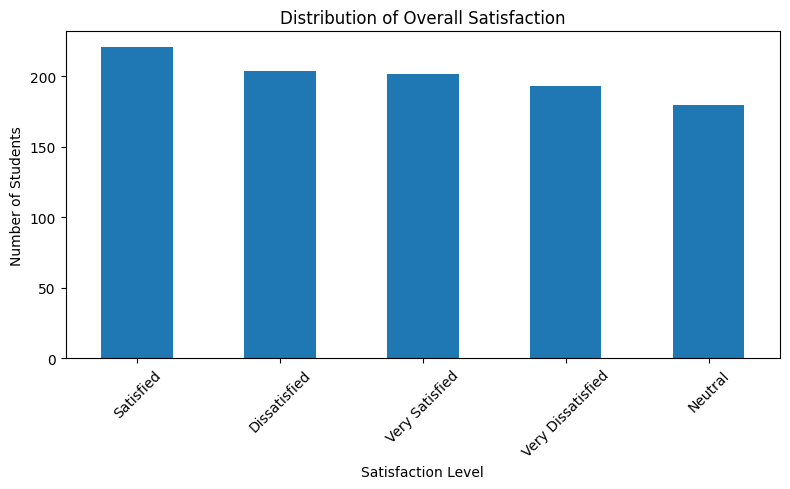

In [33]:
plt.figure(figsize=(8,5))
df["overall_satisfaction"].value_counts().plot(kind="bar")
plt.title("Distribution of Overall Satisfaction")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This bar chart visualizes the distribution of satisfaction levels. It helps to identify which satisfaction categories are most common among students.

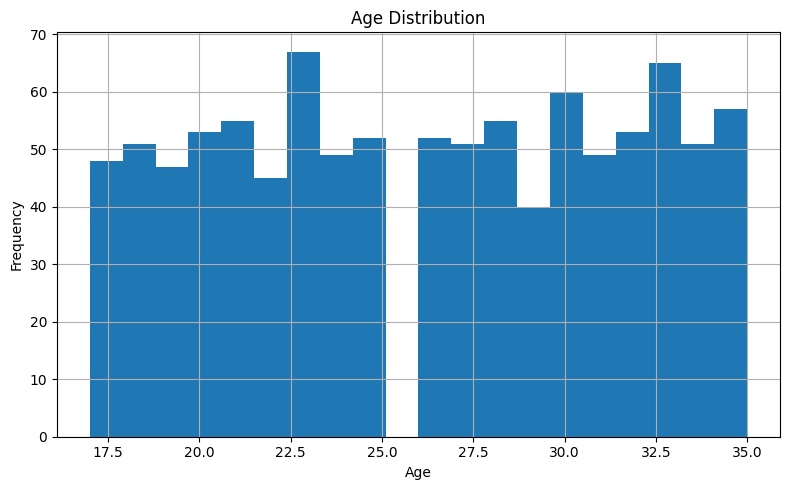

In [34]:
plt.figure(figsize=(8,5))
df["age"].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

This histogram shows the distribution of student ages. It helps to understand the spread and concentration of age values in the dataset.

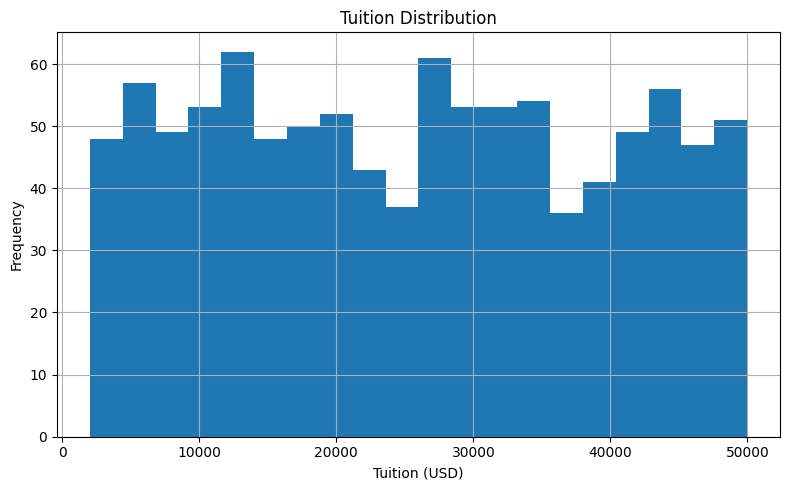

In [35]:
plt.figure(figsize=(8,5))
df["tuition_usd"].hist(bins=20)
plt.title("Tuition Distribution")
plt.xlabel("Tuition (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

This histogram visualizes the distribution of tuition fees. It helps to identify whether most students pay similar amounts or if there is a wide variation.

In [36]:
df.groupby("scholarship")["satisfaction_score"].mean()

,satisfaction_score
scholarship,
No,3.095142
Yes,2.976285


This step calculates the average satisfaction score for students with and without scholarships. It provides an initial comparison between the two groups.

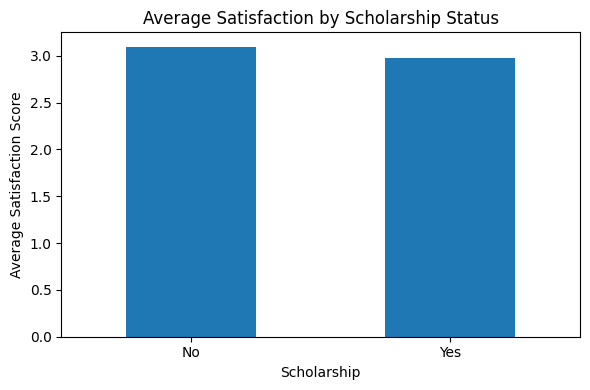

In [37]:
df.groupby("scholarship")["satisfaction_score"].mean().plot(kind="bar", figsize=(6,4))
plt.title("Average Satisfaction by Scholarship Status")
plt.xlabel("Scholarship")
plt.ylabel("Average Satisfaction Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This bar chart compares the average satisfaction scores between students who receive scholarships and those who do not.

In [38]:
df.groupby("program_level")["satisfaction_score"].mean()

,satisfaction_score
program_level,
Bachelor,3.000000
Master,3.096317
PhD,3.003185


This step calculates the average satisfaction score for different program levels, such as undergraduate or graduate students.

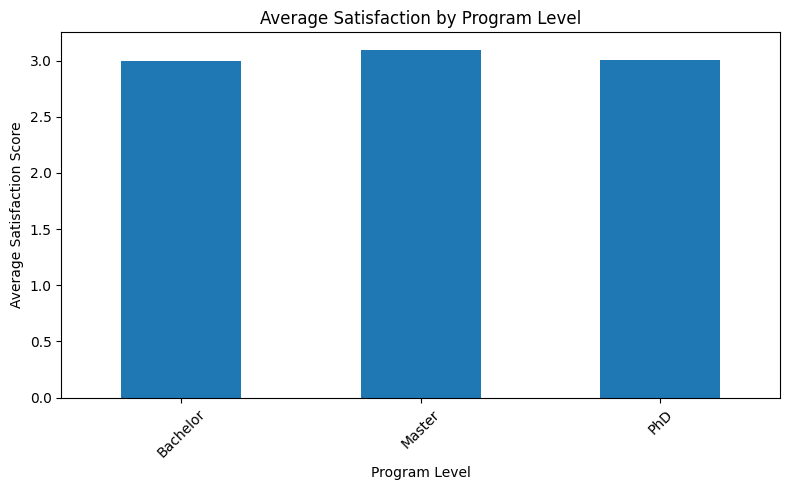

In [39]:
df.groupby("program_level")["satisfaction_score"].mean().plot(kind="bar", figsize=(8,5))
plt.title("Average Satisfaction by Program Level")
plt.xlabel("Program Level")
plt.ylabel("Average Satisfaction Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This bar chart shows how satisfaction varies across different program levels. It helps to identify which group has higher or lower satisfaction.

In [40]:
df["country"].value_counts().head(10)

,count
country,
China,93
India,88
USA,83
UAE,75
Canada,73
Malaysia,72
Australia,70
France,69
UK,69


This step displays the most frequent countries in the dataset. It provides insight into the geographical distribution of students.

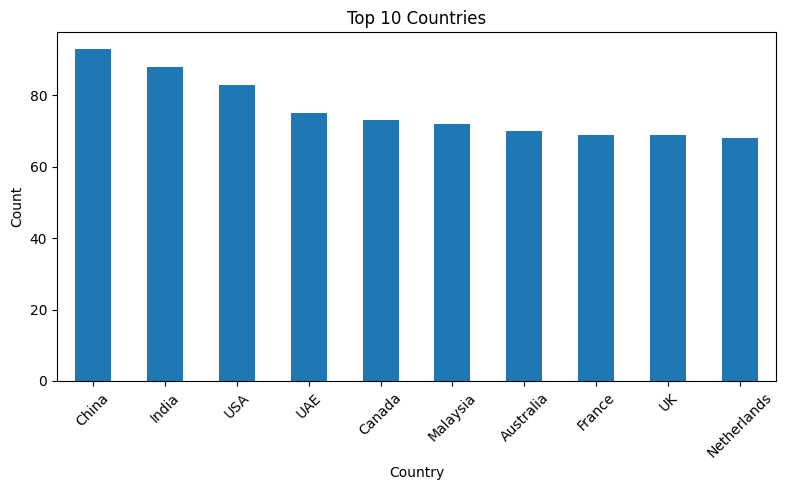

In [41]:
df["country"].value_counts().head(10).plot(kind="bar", figsize=(8,5))
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This bar chart visualizes the top countries represented in the dataset. It helps to understand the diversity of the sample.

In [42]:
corr_cols = ["age", "year_of_study", "tuition_usd", "campus_facilities_rating", "teaching_quality_rating", "satisfaction_score"]
df[corr_cols].corr(numeric_only=True)

,age,year_of_study,tuition_usd,campus_facilities_rating,teaching_quality_rating,satisfaction_score
age,1.000000,0.019948,0.047679,0.020315,-0.021303,-0.025101
year_of_study,0.019948,1.000000,0.032462,-0.003510,-0.018435,0.017024
tuition_usd,0.047679,0.032462,1.000000,0.046082,0.024403,-0.014504
campus_facilities_rating,0.020315,-0.003510,0.046082,1.000000,0.030063,-0.037002
teaching_quality_rating,-0.021303,-0.018435,0.024403,0.030063,1.000000,-0.006974
satisfaction_score,-0.025101,0.017024,-0.014504,-0.037002,-0.006974,1.000000


This step calculates the correlation between numerical variables. It helps to identify relationships between variables and their potential influence on satisfaction.

In [43]:
scholar_yes = df[df["scholarship"] == "Yes"]["satisfaction_score"]
scholar_no = df[df["scholarship"] == "No"]["satisfaction_score"]

t_stat, p_val = stats.ttest_ind(scholar_yes, scholar_no, equal_var=False)

print("p-value:", p_val)

p-value: 0.18490846432050265


This t-test compares the average satisfaction between students with and without scholarships. If the p-value is less than 0.05, the difference is considered statistically significant.

In [44]:
groups = [group["satisfaction_score"].values for _, group in df.groupby("program_level")]
f_stat, p_val_anova = stats.f_oneway(*groups)

print("p-value:", p_val_anova)

p-value: 0.5998947049188779


The ANOVA test checks whether there are significant differences in satisfaction across multiple groups. A p-value below 0.05 indicates that at least one group differs from the others.

In [45]:
contingency = pd.crosstab(df["overall_satisfaction"], df["online_classes"])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency)

print("p-value:", p_val_chi)

p-value: 0.06671673307686218


The chi-square test evaluates whether two categorical variables are independent. A low p-value suggests that there is a relationship between the variables.

## Conclusion

In this milestone, the dataset was successfully collected and analyzed. Exploratory data analysis was performed using statistical summaries and visualizations. Additionally, hypothesis tests such as t-test, ANOVA, and chi-square were applied to evaluate relationships between variables.

In the next stage, the dataset will be enriched with external data sources such as country-level indicators to improve the analysis.

# Machine Learning Milestone (5 May)
In this section, we will apply Machine Learning methods to predict the `overall_satisfaction` of students based on survey responses. Since the dataset contains a mix of numerical and categorical data, we will approach this as a **Classification** problem and compare two different models: a baseline linear model and a complex ensemble model.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
df = pd.read_csv("world_university_survey_dataset.csv")
df = df.dropna()

## 1. Data Preprocessing (Veri Ön İşleme)
Before feeding the data into machine learning algorithms, we need to prepare it:
* **Label Encoding:** ML models require numerical inputs. We convert categorical variables (like country, gender) into numerical labels.
* **Standard Scaling:** Ensures all features contribute equally by standardizing their ranges, which is especially important for distance-based and linear models like Logistic Regression.
* **Data Leakage Prevention:** We drop the `satisfaction_score` column (if it exists) as it is directly derived from our target variable `overall_satisfaction`.
* **Train-Test Split:** We split our data (80% training, 20% testing) to evaluate how well our models generalize to unseen data.

In [47]:
df_ml = df.copy()

# Prevent data leakage
if 'satisfaction_score' in df_ml.columns:
    df_ml = df_ml.drop('satisfaction_score', axis=1)

target_col = 'overall_satisfaction'

# Convert categorical features to numeric
le = LabelEncoder()
for col in df_ml.columns:
    if df_ml[col].dtype == 'object':
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# Separate features (X) and target (y)
X = df_ml.drop(target_col, axis=1)
y = df_ml[target_col]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## 2. Model 1: Logistic Regression (Baseline Model)
We use Logistic Regression as our baseline model. It helps us understand if the relationship between the features (student demographics, scores) and the target (satisfaction) is primarily linear. It is fast, interpretable, and provides a good benchmark.

In [48]:
# Initialize and train Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_log = log_model.predict(X_test)
log_acc = accuracy_score(y_test, y_pred_log)

print(f"Logistic Regression Accuracy: {log_acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 17.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.18      0.19      0.19        37
           1       0.09      0.04      0.06        47
           2       0.23      0.39      0.29        36
           3       0.21      0.19      0.20        42
           4       0.10      0.11      0.10        38

    accuracy                           0.17       200
   macro avg       0.16      0.18      0.17       200
weighted avg       0.16      0.17      0.16       200



## 3. Model 2: Random Forest Classifier
Survey data often contains complex, non-linear relationships and feature interactions (e.g., the combination of scholarship status and course difficulty might affect satisfaction differently than each feature alone). Random Forest, an ensemble learning method, builds multiple decision trees and merges them together to get a more accurate and stable prediction.

In [49]:
# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 16.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.13      0.16      0.15        37
           1       0.13      0.09      0.10        47
           2       0.16      0.25      0.19        36
           3       0.28      0.19      0.23        42
           4       0.13      0.13      0.13        38

    accuracy                           0.16       200
   macro avg       0.17      0.16      0.16       200
weighted avg       0.17      0.16      0.16       200



## 4. Evaluation and Conclusion
To finalize our ML milestone, we compare the accuracy of both models.
* **Accuracy:** The overall correct prediction rate.
* **Precision/Recall:** Shows how well the model predicts specific satisfaction levels without false positives/negatives.

/tmp/ipykernel_12622/3297812027.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette=['#3498db', '#2ecc71'])


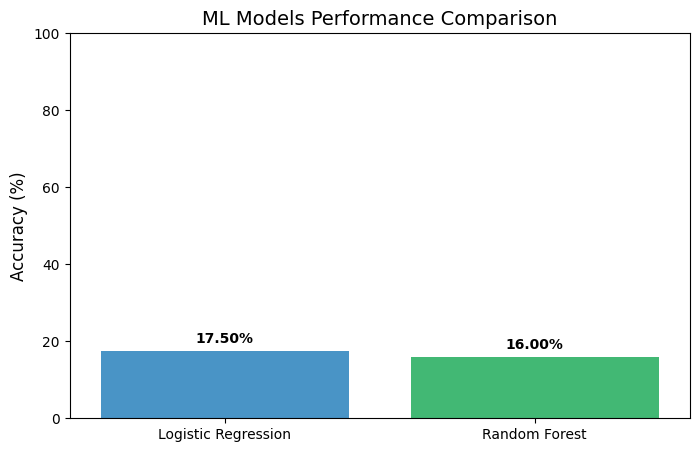

Conclusion: Logistic Regression performed equally well or better. This indicates that a simple linear model is sufficient to predict student satisfaction for this dataset.


In [50]:
# Visualize Model Comparison
models = ['Logistic Regression', 'Random Forest']
accuracies = [log_acc * 100, rf_acc * 100]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette=['#3498db', '#2ecc71'])
plt.title('ML Models Performance Comparison', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)

for i, v in enumerate(accuracies):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()

if rf_acc > log_acc:
    print("Conclusion: Random Forest outperformed Logistic Regression. This indicates that the relationships in our survey data are non-linear and complex, which the tree-based ensemble method captured better.")
else:
    print("Conclusion: Logistic Regression performed equally well or better. This indicates that a simple linear model is sufficient to predict student satisfaction for this dataset.")